In [9]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model



from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings('ignore')

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {tf.config.list_physical_devices('GPU')}")
print("Bibliotheken geladen")

TensorFlow Version: 2.20.0
GPU verfügbar: []
Bibliotheken geladen


In [10]:
# Trainingsdaten laden
train_df = pd.read_pickle('../3. Datenteilung/train.pkl')
validation_df = pd.read_pickle('../3. Datenteilung/validation.pkl')
test_df = pd.read_pickle('../3. Datenteilung/test.pkl')

print("Daten geladen:")
print(f"Training: {train_df.shape}")
print(f"Validation: {validation_df.shape}")
print(f"Test: {test_df.shape}")

# Fraud-Verteilung prüfen
print(f"\nFraud-Verteilung Training:")
print(train_df['Is_Fraud'].value_counts())
print(f"\nFraud-Rate: {train_df['Is_Fraud'].mean()*100:.2f}%")

Daten geladen:
Training: (140000, 21)
Validation: (30000, 21)
Test: (30000, 21)

Fraud-Verteilung Training:
Is_Fraud
0    132938
1      7062
Name: count, dtype: int64

Fraud-Rate: 5.04%


In [11]:
# Features und Labels trennen
X_train = train_df.drop('Is_Fraud', axis=1)
y_train = train_df['Is_Fraud']

X_val = validation_df.drop('Is_Fraud', axis=1)
y_val = validation_df['Is_Fraud']

X_test = test_df.drop('Is_Fraud', axis=1)
y_test = test_df['Is_Fraud']

print(f"Feature-Anzahl: {X_train.shape[1]}")
print(f"\nFeatures: {list(X_train.columns)}")

Feature-Anzahl: 20

Features: ['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description', 'Transaction_Day', 'Transaction_Hour', 'Transaction_Minute', 'Transaction_Second', 'Transaction_To_Balance_Ratio', 'Is_Large_Transaction']


In [12]:
# Feature-Normalisierung (wichtig für NN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features standardisiert")
print(f"Mittelwert: {X_train_scaled.mean():.6f}")
print(f"Standardabweichung: {X_train_scaled.std():.6f}")

Features standardisiert
Mittelwert: -0.000000
Standardabweichung: 1.000000


In [13]:
# Workflow A: Class Weights berechnen
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("=" * 80)
print("WORKFLOW A: CLASS WEIGHTS")
print("=" * 80)
print(f"Legitim (0): {class_weight_dict[0]:.2f}")
print(f"Betrug (1): {class_weight_dict[1]:.2f}")
print(f"Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}:1")
print(f"Trainingsdaten: {X_train_scaled.shape}")

WORKFLOW A: CLASS WEIGHTS
Legitim (0): 0.53
Betrug (1): 9.91
Ratio: 18.82:1
Trainingsdaten: (140000, 20)


In [14]:
def create_baseline_model(input_dim, learning_rate=0.001):
    """
    Einfaches Baseline-Modell
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

# Modell erstellen und anzeigen
baseline_model = create_baseline_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Callbacks definieren
early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'baseline_model_best.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks definiert")

Callbacks definiert


In [16]:
# Baseline-Modell trainieren (OHNE SMOTE, mit Class Weights)
print("=" * 80)
print("WORKFLOW A: Training Baseline-Modell mit Class Weights")
print("=" * 80)
print()

history_baseline_cw = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("\nTraining abgeschlossen")

WORKFLOW A: Training Baseline-Modell mit Class Weights

Epoch 1/100
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5232 - auc: 0.4922 - loss: 0.7086 - precision: 0.0489 - recall: 0.4621
Epoch 1: val_auc improved from -inf to 0.50076, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5232 - auc: 0.4922 - loss: 0.7085 - precision: 0.0489 - recall: 0.4622 - val_accuracy: 0.3288 - val_auc: 0.5008 - val_loss: 0.7054 - val_precision: 0.0513 - val_recall: 0.7032 - learning_rate: 0.0010
Epoch 2/100
542/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4633 - auc: 0.5161 - loss: 0.6950 - precision: 0.0520 - recall: 0.5565
Epoch 2: val_auc improved from 0.50076 to 0.50623, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4635 - auc: 0.5161 - loss: 0.6950 - precision: 0.0520 - recall: 0.5563 - val_accuracy: 0.4484 - val_auc: 0.5062 - val_loss: 0.6946 - val_precision: 0.0521 - val_recall: 0.5783 - learning_rate: 0.0010
Epoch 3/100
528/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5358 - auc: 0.5132 - loss: 0.6878 - precision: 0.0510 - recall: 0.4738
Epoch 3: val_auc improved from 0.50623 to 0.50901, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5346 - auc: 0.5132 - loss: 0.6880 - precision: 0.0510 - recall: 0.4752 - val_accuracy: 0.2934 - val_auc: 0.5090 - val_loss: 0.7024 - val_precision: 0.0510 - val_recall: 0.7389 - learning_rate: 0.0010
Epoch 4/100
523/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4337 - auc: 0.5133 - loss: 0.6981 - precision: 0.0525 - recall: 0.5893
Epoch 4: val_auc improved from 0.50901 to 0.50945, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4370 - auc: 0.5134 - loss: 0.6978 - precision: 0.0525 - recall: 0.5857 - val_accuracy: 0.3393 - val_auc: 0.5094 - val_loss: 0.7003 - val_precision: 0.0514 - val_recall: 0.6927 - learning_rate: 0.0010
Epoch 5/100
544/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4930 - auc: 0.5218 - loss: 0.6906 - precision: 0.0527 - recall: 0.5365
Epoch 5: val_auc improved from 0.50945 to 0.51852, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4928 - auc: 0.5218 - loss: 0.6906 - precision: 0.0527 - recall: 0.5366 - val_accuracy: 0.4688 - val_auc: 0.5185 - val_loss: 0.6927 - val_precision: 0.0530 - val_recall: 0.5651 - learning_rate: 0.0010
Epoch 6/100
541/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5379 - auc: 0.5262 - loss: 0.6852 - precision: 0.0527 - recall: 0.4920
Epoch 6: val_auc did not improve from 0.51852
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5376 - auc: 0.5261 - loss: 0.6853 - precision: 0.0527 - recall: 0.4923 - val_accuracy: 0.1517 - val_auc: 0.5141 - val_loss: 0.7120 - val_precision: 0.0508 - val_recall: 0.8936 - learning_rate: 0.0010
Epoch 7/100
532/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3832 - auc: 0.5243 - loss: 0.6909 - precision: 0.0526 - recall: 0.6627
Epoch 7: val_auc did not improve from 0.51852
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3843 - auc: 0.5242 - loss: 0.6909 - precision: 0.0526 - recall: 0.6

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4829 - auc: 0.5301 - loss: 0.6889 - precision: 0.0534 - recall: 0.5587 - val_accuracy: 0.4418 - val_auc: 0.5199 - val_loss: 0.6943 - val_precision: 0.0528 - val_recall: 0.5948 - learning_rate: 0.0010
Epoch 11/100
525/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5080 - auc: 0.5301 - loss: 0.6879 - precision: 0.0538 - recall: 0.5335
Epoch 11: val_auc improved from 0.51985 to 0.52062, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5065 - auc: 0.5299 - loss: 0.6881 - precision: 0.0537 - recall: 0.5349 - val_accuracy: 0.3939 - val_auc: 0.5206 - val_loss: 0.6970 - val_precision: 0.0535 - val_recall: 0.6596 - learning_rate: 0.0010
Epoch 12/100
531/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5040 - auc: 0.5397 - loss: 0.6887 - precision: 0.0555 - recall: 0.5554
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: val_auc did not improve from 0.52062
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5035 - auc: 0.5395 - loss: 0.6888 - precision: 0.0555 - recall: 0.5557 - val_accuracy: 0.5136 - val_auc: 0.5077 - val_loss: 0.6864 - val_precision: 0.0530 - val_recall: 0.5122 - learning_rate: 0.0010
Epoch 13/100
523/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5312 - auc: 0.5390 - loss: 0.6853 - precision: 0.0545 - recall: 0.5160
Epoch 13: val_auc did not improve from 0.52062
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

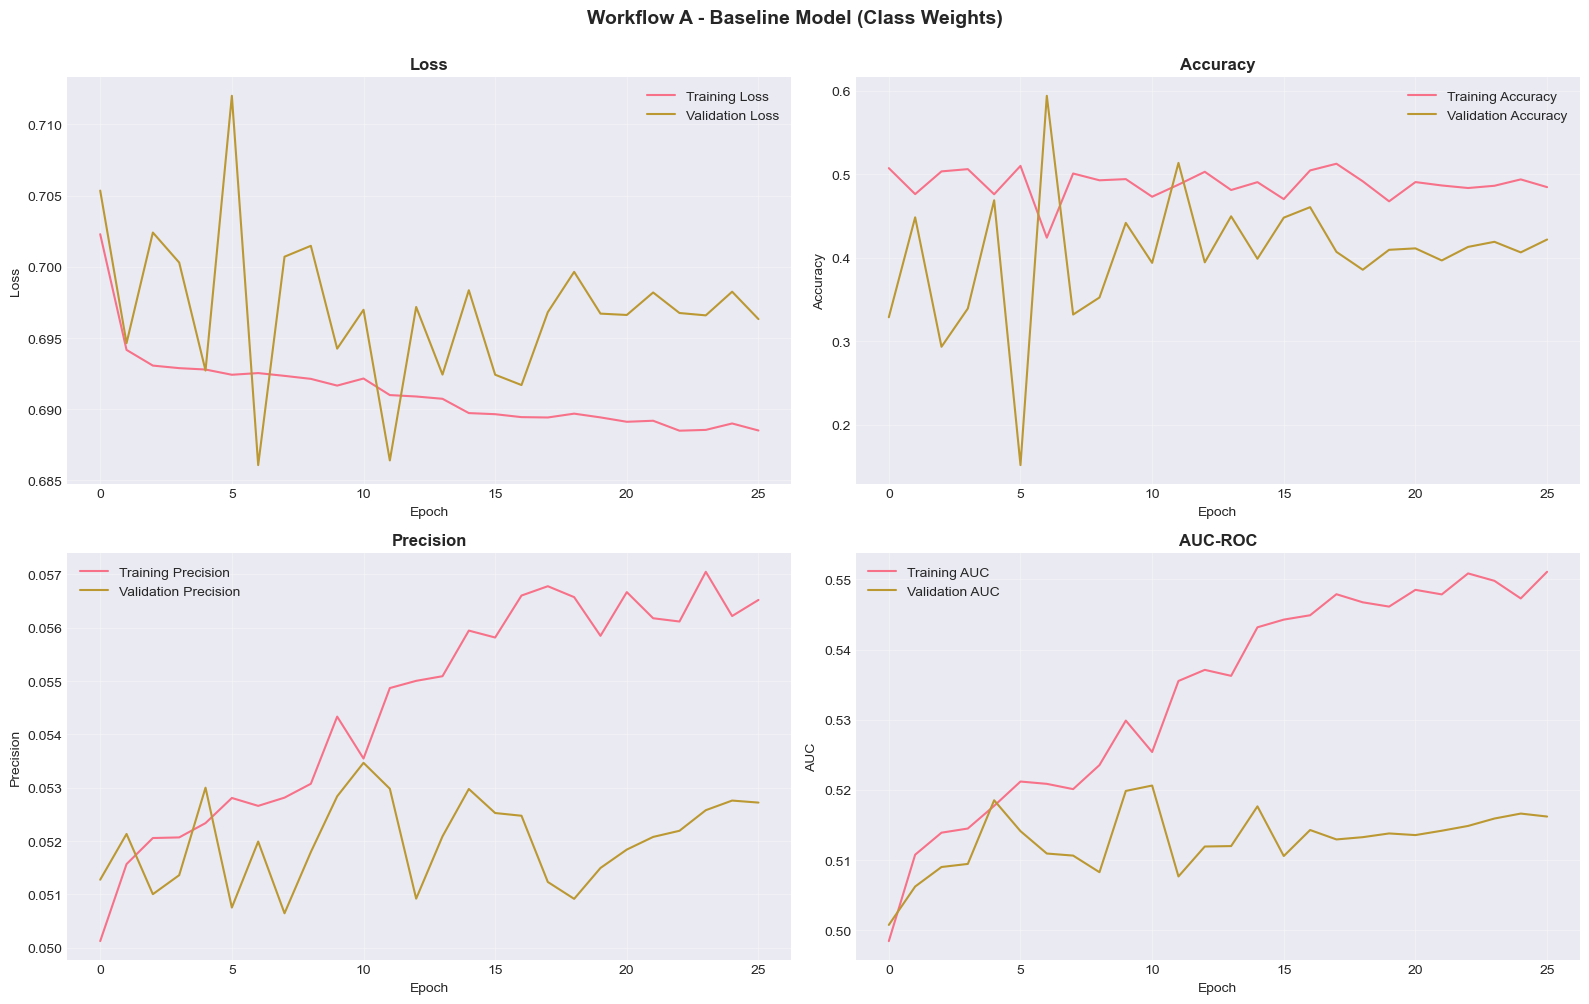

In [17]:
# Training-History visualisieren
def plot_training_history(history, title="Training History"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Loss', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 1].set_title('Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Precision', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # AUC
    axes[1, 1].plot(history.history['auc'], label='Training AUC')
    axes[1, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1, 1].set_title('AUC-ROC', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_training_history(history_baseline_cw, "Workflow A - Baseline Model (Class Weights)")

EVALUATION: Workflow A - Baseline (Class Weights)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      0.38      0.55     28487
      Betrug       0.05      0.60      0.09      1513

    accuracy                           0.39     30000
   macro avg       0.50      0.49      0.32     30000
weighted avg       0.90      0.39      0.52     30000

AUC-ROC Score: 0.5028


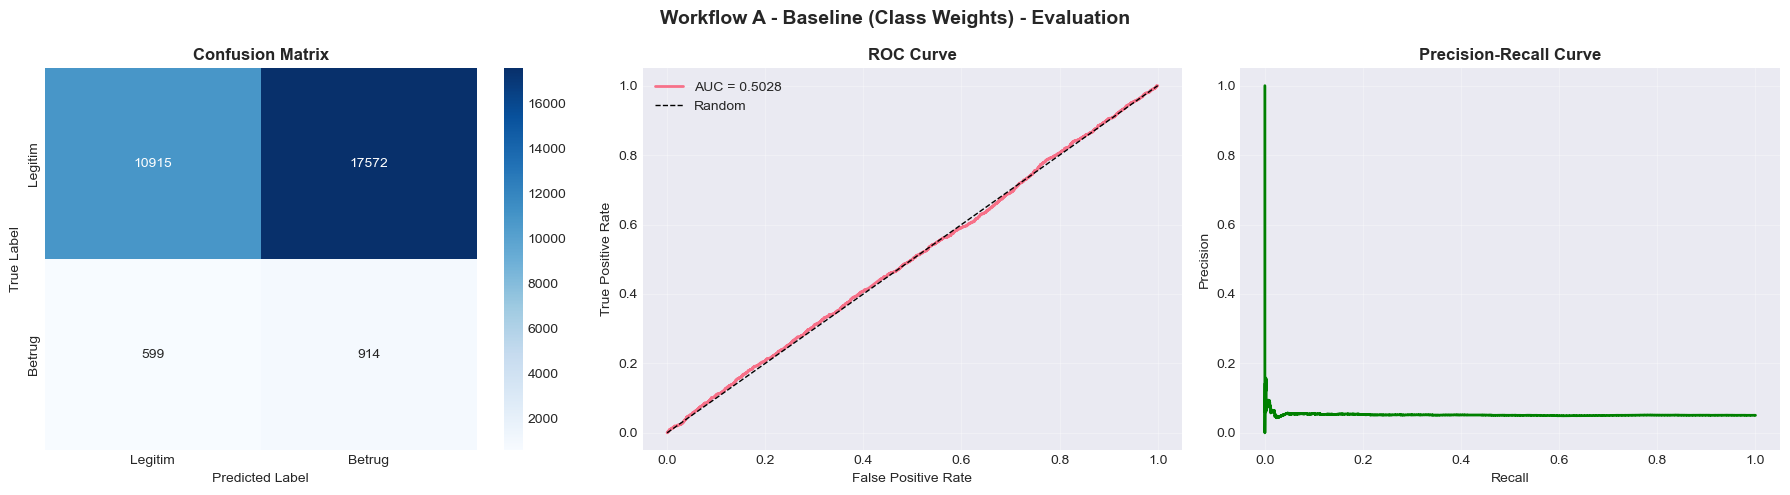


Zusätzliche Metriken:
True Negatives: 10915
False Positives: 17572
False Negatives: 599
True Positives: 914
Specificity (True Negative Rate): 0.3832
Sensitivity (True Positive Rate/Recall): 0.6041


In [18]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Umfassende Modell-Evaluation
    """
    # Vorhersagen
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Metriken berechnen
    print("=" * 80)
    print(f"EVALUATION: {model_name}")
    print("=" * 80)
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Legitim', 'Betrug']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # AUC-ROC
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC-ROC Score: {auc_score:.4f}")
    
    # Visualisierungen
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legitim', 'Betrug'],
                yticklabels=['Legitim', 'Betrug'])
    axes[0].set_title('Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    axes[2].plot(recall, precision, linewidth=2, color='green')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].grid(alpha=0.3)
    
    plt.suptitle(f'{model_name} - Evaluation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Zusätzliche Metriken
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    
    print("\nZusätzliche Metriken:")
    print(f"True Negatives: {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives: {tp}")
    print(f"Specificity (True Negative Rate): {specificity:.4f}")
    print(f"Sensitivity (True Positive Rate/Recall): {sensitivity:.4f}")
    
    return {
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
        'auc': auc_score,
        'confusion_matrix': cm
    }

# Baseline-Modell evaluieren (Class Weights)
baseline_cw_results = evaluate_model(baseline_model, X_test_scaled, y_test, "Workflow A - Baseline (Class Weights)")

### LIME (Local Interpretable Model-agnostic Explanations)

--> versucht lokal um eine einzelne Vorhersage herum ein einfaches, erklärbares Modell zu bauen (lineare Regression, Entscheidungsbaum...)


In [19]:
# LIME-Instanz anlegen
explainer = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns,
    class_names=['Kein Betrug', 'Betrug'],
    mode='classification'
)

# Beispielhafte Transaktion aus Testdaten
i = 12  # beliebiger Index
sample = X_test_scaled[i]

# Vorhersagefunktion definieren (muss 2D und Wahrscheinlichkeiten liefern)
predict_fn = lambda x: np.array([baseline_model.predict(x)]).squeeze().reshape(-1,1)

# Erklärung erzeugen
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=lambda x: np.column_stack((1 - baseline_model.predict(x), baseline_model.predict(x))),
    num_features=10
)

# Ergebnisse anzeigen
exp.show_in_notebook(show_table=True)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step


Die Zahlen sind Gewichte im linearen Modell. Positive Werte → treiben die Vorhersage in Richtung Betrug, negative → in Richtung Kein Betrug.

Hohe positive Werte (z. B. Transaction_To_Balance_Ratio=1.61, Device_Type=1.34) → diese Features „überzeugen“ das Modell, dass die Transaktion Betrug sein könnte.

Hohe negative Werte (z. B. Account_Balance=-1.5, Transaction_Hour=-0.94) → diese Features wirken stark gegen die Betrugsklasse.

Da sich positive und negative Einflüsse hier ungefähr ausgleichen, erklärt sich auch die 50 / 50 Wahrscheinlichkeit.